In [2]:
import os, pickle, torch, torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm


def find_image_dir():
    # Common Kaggle root
    base_input = '/kaggle/input'

    # Walk through the input directory to find where the images actually are
    for root, dirs, files in os.walk(base_input):
        # Look for the folder containing a high volume of jpg files
        if len([f for f in files if f.endswith('.jpg')]) > 1000:
            return root
    return None


IMAGE_DIR = find_image_dir()
OUTPUT_FILE = 'flickr30k_features.pkl'

if IMAGE_DIR:
    print(f" Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError(
        "Could not find the Flickr30k image directory. Please ensure the dataset "
        "is added to the notebook."
    )


# --- THE DATASET CLASS ---
class FlickrDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_names = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.jpeg'))
        ]
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, name)
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), name


# --- REMAINDER OF THE PIPELINE (AS BEFORE) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1])  # Feature vector only
model = nn.DataParallel(model).to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

dataset = FlickrDataset(IMAGE_DIR, transform)
loader = DataLoader(dataset, batch_size=128, num_workers=4)

features_dict = {}

with torch.no_grad():
    for imgs, names in tqdm(loader, desc="Extracting Features"):
        feats = model(imgs.to(device)).view(imgs.size(0), -1)
        for i, name in enumerate(names):
            features_dict[name] = feats[i].cpu().numpy()

with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(f"Success! {len(features_dict)} images processed and saved to {OUTPUT_FILE}")


 Found images at: /kaggle/input/datasets/adityajn105/flickr30k/Images


Extracting Features: 100%|██████████| 249/249 [01:32<00:00,  2.69it/s]


Success! 31783 images processed and saved to flickr30k_features.pkl


In [3]:
import re
import pickle
from collections import Counter
import torch
from torch.nn.utils.rnn import pad_sequence

CAPTIONS_FILE = "/kaggle/input/datasets/adityajn105/flickr30k/captions.txt"


# Load captions
image_captions = []

with open(CAPTIONS_FILE, "r", encoding="utf-8") as f:
    next(f)  # skip header
    for line in f:
        line = line.strip()
        if not line:
            continue
        img, caption = line.split(",", 1)  # split only on first comma
        image_captions.append((img.strip(), caption.strip()))

print(f"Total image-caption pairs: {len(image_captions)}")

# Text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

START_TOKEN = "<start>"
END_TOKEN = "<end>"
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

cleaned_data = []
for img, caption in image_captions:
    caption = clean_text(caption)
    caption = f"{START_TOKEN} {caption} {END_TOKEN}"
    cleaned_data.append((img, caption))


# Build vocabulary
word_freq = Counter()
for _, caption in cleaned_data:
    word_freq.update(caption.split())

MIN_FREQ = 5

vocab = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]
vocab += [w for w, c in word_freq.items() if c >= MIN_FREQ]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size: {len(vocab)}")

# Convert captions to sequences
def caption_to_seq(caption):
    return [
        word2idx.get(word, word2idx[UNK_TOKEN])
        for word in caption.split()
    ]

sequences = [torch.tensor(caption_to_seq(caption)) for _, caption in cleaned_data]

# Pad sequences
PAD_IDX = word2idx[PAD_TOKEN]

padded_captions = pad_sequence(
    sequences,
    batch_first=True,
    padding_value=PAD_IDX
)

max_caption_length = padded_captions.size(1)
print("Max caption length:", max_caption_length)

# Save preprocessing outputs
with open("flickr30k_vocab.pkl", "wb") as f:
    pickle.dump({
        "word2idx": word2idx,
        "idx2word": idx2word,
        "vocab_size": len(vocab),
        "max_caption_length": max_caption_length
    }, f)

with open("flickr30k_captions_processed.pkl", "wb") as f:
    pickle.dump(cleaned_data, f)

Total image-caption pairs: 158915
Vocabulary size: 7691
Max caption length: 80


In [13]:
import torch
import torch.nn as nn

# Encoder
class ImageEncoder(nn.Module):
    def __init__(self, feature_dim=2048, hidden_size=512):
        super(ImageEncoder, self).__init__()
        self.fc = nn.Linear(feature_dim, hidden_size)

    def forward(self, image_features):
        """
        image_features: (batch_size, 2048)
        returns: (batch_size, hidden_size)
        """
        encoded = self.fc(image_features)
        return encoded

# Decoder
class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, num_layers=1):
        super(CaptionDecoder, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, captions, hidden_state):
        """
        captions: (batch_size, seq_len)
        hidden_state: (batch_size, hidden_size) from encoder
        """

        # Embed words
        embeddings = self.embedding(captions)

        # Prepare initial hidden & cell state
        h0 = hidden_state.unsqueeze(0)  # (1, batch_size, hidden_size)
        c0 = torch.zeros_like(h0)       # same shape as h0

        # LSTM forward
        outputs, _ = self.lstm(embeddings, (h0, c0))

        # Vocabulary scores
        outputs = self.fc(outputs)  # (batch_size, seq_len, vocab_size)

        return outputs



# Full Seq2Seq Model
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, feature_dim=2048, embed_size=256, hidden_size=512):
        super(ImageCaptioningModel, self).__init__()

        self.encoder = ImageEncoder(feature_dim, hidden_size)
        self.decoder = CaptionDecoder(vocab_size, embed_size, hidden_size)

    def forward(self, image_features, captions):
        """
        image_features: (batch_size, 2048)
        captions: (batch_size, seq_len)
        """
        encoded_features = self.encoder(image_features)
        outputs = self.decoder(captions, encoded_features)
        return outputs


In [14]:
!pip install nltk

# Training & Inference
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu


# Load artifacts
with open("flickr30k_vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

word2idx = vocab_data["word2idx"]
idx2word = vocab_data["idx2word"]
vocab_size = vocab_data["vocab_size"]

PAD_IDX = word2idx["<pad>"]
START_IDX = word2idx["<start>"]
END_IDX = word2idx["<end>"]

with open("flickr30k_captions_processed.pkl", "rb") as f:
    captions_data = pickle.load(f)

with open("flickr30k_features.pkl", "rb") as f:
    image_features = pickle.load(f)


# Dataset
class CaptionDataset(Dataset):
    def __init__(self, captions_data, image_features, word2idx):
        self.data = captions_data
        self.image_features = image_features
        self.word2idx = word2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, caption = self.data[idx]
        feature = torch.tensor(self.image_features[img], dtype=torch.float)

        tokens = caption.split()
        ids = [self.word2idx.get(w, self.word2idx["<unk>"]) for w in tokens]

        return feature, torch.tensor(ids[:-1]), torch.tensor(ids[1:])

def collate_fn(batch):
    features, inputs, targets = zip(*batch)
    features = torch.stack(features)
    inputs = nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=PAD_IDX)
    targets = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_IDX)
    return features, inputs, targets


# Train / Validation Split
dataset = CaptionDataset(captions_data, image_features, word2idx)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

# Seq2Seq Model
class ImageEncoder(nn.Module):
    def __init__(self, feature_dim=2048, hidden_size=512):
        super().__init__()
        self.fc = nn.Linear(feature_dim, hidden_size)

    def forward(self, x):
        return self.fc(x)

class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, captions, hidden):
        emb = self.embedding(captions)
        h0 = hidden.unsqueeze(0)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc(out)

class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = ImageEncoder()
        self.decoder = CaptionDecoder(vocab_size)

    def forward(self, features, captions):
        hidden = self.encoder(features)
        return self.decoder(captions, hidden)


# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImageCaptioningModel(vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop + Validation + BLEU
EPOCHS = 20

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    total_loss = 0

    for features, cap_in, cap_out in train_loader:
        features = features.to(device)
        cap_in = cap_in.to(device)
        cap_out = cap_out.to(device)

        optimizer.zero_grad()
        outputs = model(features, cap_in)

        loss = criterion(
            outputs.reshape(-1, vocab_size),
            cap_out.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- Validation ----
    model.eval()
    val_loss = 0
    references = []
    hypotheses = []

    with torch.no_grad():
        for features, cap_in, cap_out in val_loader:
            features = features.to(device)
            cap_in = cap_in.to(device)
            cap_out = cap_out.to(device)

            outputs = model(features, cap_in)

            loss = criterion(
                outputs.reshape(-1, vocab_size),
                cap_out.reshape(-1)
            )
            val_loss += loss.item()

            preds = outputs.argmax(dim=-1)

            for i in range(preds.size(0)):
                pred_sentence = []
                target_sentence = []

                for w in preds[i]:
                    if w.item() == END_IDX:
                        break
                    if w.item() != PAD_IDX:
                        pred_sentence.append(idx2word[w.item()])

                for w in cap_out[i]:
                    if w.item() == END_IDX:
                        break
                    if w.item() != PAD_IDX:
                        target_sentence.append(idx2word[w.item()])

                if len(pred_sentence) > 0 and len(target_sentence) > 0:
                    hypotheses.append(pred_sentence)
                    references.append([target_sentence])

    bleu = corpus_bleu(references, hypotheses) if len(hypotheses) > 0 else 0

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {total_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | "
        f"BLEU: {bleu:.4f}"
    )

# Save Model
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
    "hidden_size": 512,
    "embed_size": 256
}, "image_captioning_seq2seq.pt")

print("Model saved as image_captioning_seq2seq.pt")

# Greedy Search
def greedy_search(model, image_feature, max_len=20):
    model.eval()
    feature = torch.tensor(image_feature).unsqueeze(0).to(device)
    hidden = model.encoder(feature)

    seq = [START_IDX]

    for _ in range(max_len):
        inp = torch.tensor(seq).unsqueeze(0).to(device)
        out = model.decoder(inp, hidden)
        next_word = out[:, -1].argmax(-1).item()

        if next_word == END_IDX:
            break
        seq.append(next_word)

    return " ".join(idx2word[w] for w in seq[1:])

# Beam Search
def beam_search(model, image_feature, beam_width=3, max_len=20):
    model.eval()
    feature = torch.tensor(image_feature).unsqueeze(0).to(device)
    hidden = model.encoder(feature)

    beams = [([START_IDX], 0.0)]

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == END_IDX:
                new_beams.append((seq, score))
                continue

            inp = torch.tensor(seq).unsqueeze(0).to(device)
            out = model.decoder(inp, hidden)
            probs = torch.softmax(out[:, -1], dim=-1)

            topk = torch.topk(probs, beam_width)
            for i in range(beam_width):
                w = topk.indices[0][i].item()
                p = topk.values[0][i].item()
                new_beams.append((seq + [w], score - torch.log(torch.tensor(p))))

        beams = sorted(new_beams, key=lambda x: x[1])[:beam_width]

    best_seq = beams[0][0][1:-1]
    return " ".join(idx2word[w] for w in best_seq)


Epoch [1/20] Train Loss: 4.4746 | Val Loss: 3.9273 | BLEU: 0.0427
Epoch [2/20] Train Loss: 3.7044 | Val Loss: 3.5580 | BLEU: 0.0515
Epoch [3/20] Train Loss: 3.4188 | Val Loss: 3.3665 | BLEU: 0.0580
Epoch [4/20] Train Loss: 3.2461 | Val Loss: 3.2430 | BLEU: 0.0631
Epoch [5/20] Train Loss: 3.1216 | Val Loss: 3.1555 | BLEU: 0.0660
Epoch [6/20] Train Loss: 3.0250 | Val Loss: 3.0895 | BLEU: 0.0690
Epoch [7/20] Train Loss: 2.9448 | Val Loss: 3.0386 | BLEU: 0.0722
Epoch [8/20] Train Loss: 2.8767 | Val Loss: 2.9971 | BLEU: 0.0723
Epoch [9/20] Train Loss: 2.8175 | Val Loss: 2.9639 | BLEU: 0.0741
Epoch [10/20] Train Loss: 2.7640 | Val Loss: 2.9370 | BLEU: 0.0755
Epoch [11/20] Train Loss: 2.7159 | Val Loss: 2.9147 | BLEU: 0.0744
Epoch [12/20] Train Loss: 2.6718 | Val Loss: 2.8965 | BLEU: 0.0769
Epoch [13/20] Train Loss: 2.6304 | Val Loss: 2.8794 | BLEU: 0.0775
Epoch [14/20] Train Loss: 2.5915 | Val Loss: 2.8673 | BLEU: 0.0770
Epoch [15/20] Train Loss: 2.5546 | Val Loss: 2.8550 | BLEU: 0.0811
Epoc


========== TESTING ON 5 IMAGES ==========

Image 1: 405331006.jpg
  Greedy: a man in a blue shirt is riding a white horse
  Beam 3: a man in a blue shirt is riding a white horse


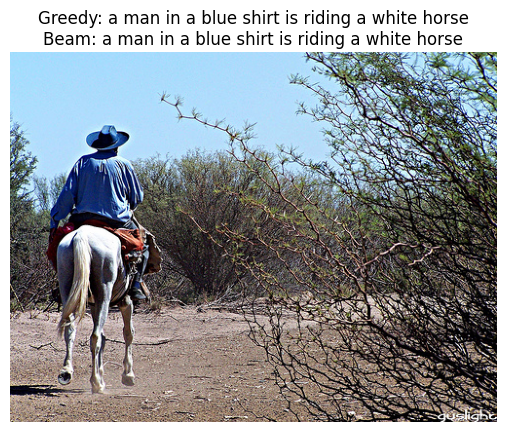

----------------------------------------------------------------------
Image 2: 3294717824.jpg
  Greedy: a surfer in a wetsuit is riding a wave
  Beam 3: a surfer in a black wetsuit rides a wave


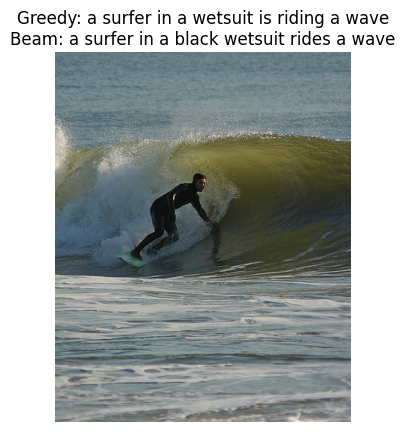

----------------------------------------------------------------------
Image 3: 4530524963.jpg
  Greedy: a busy city street with people walking by
  Beam 3: a city street with people walking by


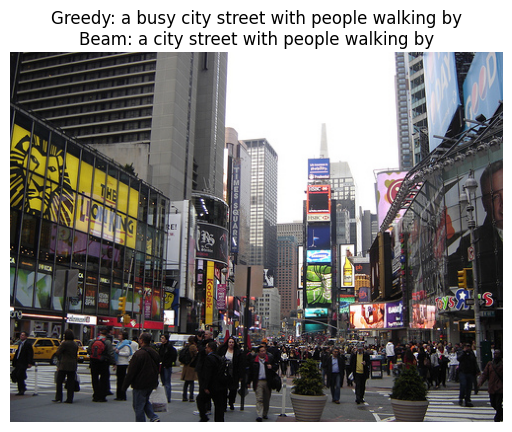

----------------------------------------------------------------------
Image 4: 3650986674.jpg
  Greedy: a dog and a dog are standing on the beach
  Beam 3: a black dog and a brown dog are standing on the beach


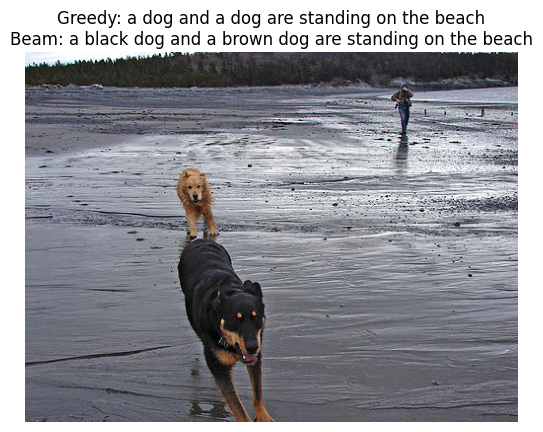

----------------------------------------------------------------------
Image 5: 762947607.jpg
  Greedy: a man in a red shirt is walking in the grass
  Beam 3: a man in a red shirt is standing in the grass


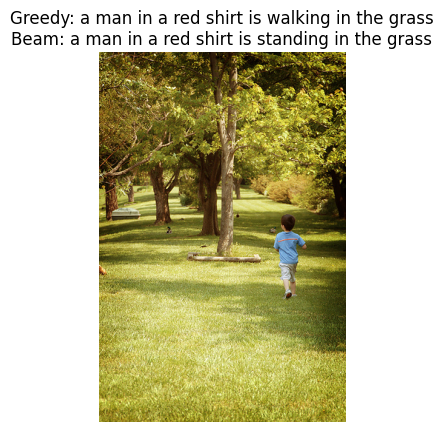

----------------------------------------------------------------------


In [15]:

# Inference 

import pickle
import torch
import torch.nn as nn
import random
import os
from PIL import Image
import matplotlib.pyplot as plt


# USER CONFIGURATION 
IMAGE_ROOT_DIR = "/kaggle/input/datasets/adityajn105/flickr30k/Images"

# Load vocabulary
with open("flickr30k_vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

word2idx = vocab_data["word2idx"]
idx2word = vocab_data["idx2word"]
vocab_size = vocab_data["vocab_size"]

PAD_IDX = word2idx["<pad>"]
START_IDX = word2idx["<start>"]
END_IDX = word2idx["<end>"]

# Load cached image features
with open("flickr30k_features.pkl", "rb") as f:
    image_features = pickle.load(f)


# Model definition
class ImageEncoder(nn.Module):
    def __init__(self, feature_dim=2048, hidden_size=512):
        super().__init__()
        self.fc = nn.Linear(feature_dim, hidden_size)

    def forward(self, x):
        return self.fc(x)

class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, captions, hidden):
        emb = self.embedding(captions)
        h0 = hidden.unsqueeze(0)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc(out)

class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = ImageEncoder()
        self.decoder = CaptionDecoder(vocab_size)

    def forward(self, features, captions):
        hidden = self.encoder(features)
        return self.decoder(captions, hidden)

# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("image_captioning_seq2seq.pt", map_location=device)

model = ImageCaptioningModel(vocab_size).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Greedy search
def greedy_search(model, image_feature, max_len=20):
    feature = torch.tensor(image_feature).unsqueeze(0).to(device)
    hidden = model.encoder(feature)

    seq = [START_IDX]

    for _ in range(max_len):
        inp = torch.tensor(seq).unsqueeze(0).to(device)
        out = model.decoder(inp, hidden)
        next_word = out[:, -1].argmax(-1).item()

        if next_word == END_IDX:
            break
        seq.append(next_word)

    return " ".join(idx2word[w] for w in seq[1:])

# Beam search
def beam_search(model, image_feature, beam_width=3, max_len=20):
    feature = torch.tensor(image_feature).unsqueeze(0).to(device)
    hidden = model.encoder(feature)

    beams = [([START_IDX], 0.0)]

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == END_IDX:
                new_beams.append((seq, score))
                continue

            inp = torch.tensor(seq).unsqueeze(0).to(device)
            out = model.decoder(inp, hidden)
            probs = torch.softmax(out[:, -1], dim=-1)

            topk = torch.topk(probs, beam_width)  
            for i in range(beam_width):
                w = topk.indices[0][i].item()
                p = topk.values[0][i].item()
                new_beams.append((seq + [w], score - torch.log(torch.tensor(p))))

        beams = sorted(new_beams, key=lambda x: x[1])[:beam_width]

    best_seq = beams[0][0][1:-1]
    return " ".join(idx2word[w] for w in best_seq)


# Automatically find image path
def find_image_path(root_dir, image_name):
    for root, _, files in os.walk(root_dir):
        if image_name in files:
            return os.path.join(root, image_name)
    return None


# Test on 5 images

print("\n========== TESTING ON 5 IMAGES ==========\n")

image_names = list(image_features.keys())
sample_images = random.sample(image_names, 5)

for i, img_name in enumerate(sample_images, 1):
    feature = image_features[img_name]

    greedy_caption = greedy_search(model, feature)
    beam_caption = beam_search(model, feature, beam_width=3)

    image_path = find_image_path(IMAGE_ROOT_DIR, img_name)

    print(f"Image {i}: {img_name}")
    print("  Greedy:", greedy_caption)
    print("  Beam 3:", beam_caption)

    if image_path is not None:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Greedy: {greedy_caption}\nBeam: {beam_caption}")
        plt.show()
    else:
        print("⚠️ Image not found in directory")

    print("-" * 70)


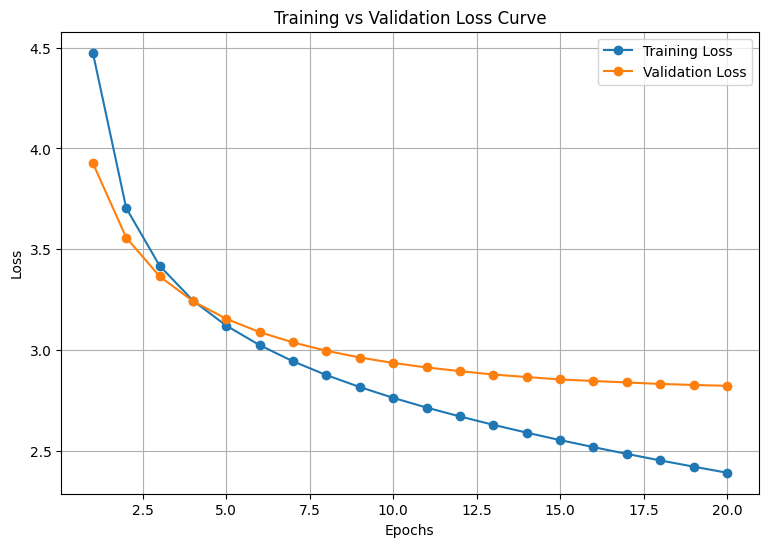

In [16]:
import matplotlib.pyplot as plt

train_losses = [
    4.4746, 3.7044, 3.4188, 3.2461, 3.1216,
    3.0250, 2.9448, 2.8767, 2.8175, 2.7640,
    2.7159, 2.6718, 2.6304, 2.5915, 2.5546,
    2.5197, 2.4863, 2.4539, 2.4231, 2.3929
]

val_losses = [
    3.9273, 3.5580, 3.3665, 3.2430, 3.1555,
    3.0895, 3.0386, 2.9971, 2.9639, 2.9370,
    2.9147, 2.8965, 2.8794, 2.8673, 2.8550,
    2.8476, 2.8402, 2.8330, 2.8278, 2.8237
]

epochs = range(1, 21)

plt.figure(figsize=(9,6))
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()
